# Bimodal and skewed density fitting report

This notebook reads generated CSV/PNG outputs and summarizes fixed-scenario fitting plus randomized quality-search results.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
OUTPUTS = ROOT / 'outputs'
fit_summary = pd.read_csv(OUTPUTS / 'fit_summary.csv')
random_summary = pd.read_csv(OUTPUTS / 'random_search_summary.csv')
fit_summary.head()

,scenario,scenario_description,model,nll,aic,bic,loglik,converged,mode_count_grid,message,...,param_alpha,param_lambda,param_sep,param_skew,param_gamma,param_weight,param_mu1,param_sigma1,param_mu2,param_sigma2
0,normal_unimodal,single symmetric Gaussian,normal,553.045352,1110.090705,1118.073634,-553.045352,True,1,closed-form MLE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,normal_unimodal,single symmetric Gaussian,ntpn,552.229565,1112.459130,1128.424988,-552.229565,True,1,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,...,-0.035846,0.754547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,normal_unimodal,single symmetric Gaussian,adn,552.229565,1112.459131,1128.424989,-552.229565,True,1,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,...,NaN,NaN,0.754957,0.045099,NaN,NaN,NaN,NaN,NaN,NaN
3,normal_unimodal,single symmetric Gaussian,abn,552.229566,1112.459133,1128.424991,-552.229566,True,1,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,...,0.027130,0.754475,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,normal_unimodal,single symmetric Gaussian,bsn_fs,552.231828,1112.463655,1128.429514,-552.231828,True,1,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,...,0.264278,NaN,NaN,NaN,0.99538,NaN,NaN,NaN,NaN,NaN


## Best model per fixed scenario by BIC

In [2]:
best_fixed = fit_summary.loc[
    fit_summary.groupby('scenario')['bic'].idxmin(),
    ['scenario', 'model', 'bic', 'mode_count_grid'],
]
best_fixed.sort_values('scenario')

,scenario,model,bic,mode_count_grid
0,normal_unimodal,normal,1118.073634,1
6,overlapping_gmm2,gmm2,1272.015792,2
12,skewed_bimodal_mixture,gmm2,1289.047499,2
18,skewed_unimodal,bsn_fs,836.094421,1
24,symmetric_bimodal,adn,1370.922745,2


## Randomized quality-search: best fitted result

In [3]:
best_random = random_summary.sort_values('quality_score', ascending=False).iloc[0]
best_random[[
    'trial_id', 'true_family', 'model', 'quality_score',
    'ise_to_true_pdf', 'bic', 'true_mode_count', 'fitted_mode_count',
]]

trial_id                      11
true_family               normal
model                     normal
quality_score         131.942158
ise_to_true_pdf         0.000058
bic                  1116.563813
true_mode_count                1
fitted_mode_count              1
Name: 0, dtype: object

## Top randomized candidates

In [4]:
random_summary.sort_values('quality_score', ascending=False)[[
    'trial_id', 'true_family', 'model', 'quality_score',
    'ise_to_true_pdf', 'bic', 'true_mode_count', 'fitted_mode_count',
]].head(10)

,trial_id,true_family,model,quality_score,ise_to_true_pdf,bic,true_mode_count,fitted_mode_count
0,11,normal,normal,131.942158,0.000058,1116.563813,1,1
1,23,skewnorm,adn,131.902714,0.000051,513.917376,1,1
2,3,bsn_fs,bsn_fs,131.861385,0.000139,776.078510,1,1
3,19,abn,ntpn,131.855330,0.000143,1478.942777,2,2
4,19,abn,abn,131.854411,0.000144,1478.933604,2,2
5,19,abn,adn,131.853999,0.000145,1478.929113,2,2
6,7,normal,normal,131.795305,0.000205,645.855487,1,1
7,19,abn,bsn_fs,131.683749,0.000316,1478.901699,2,2
8,21,normal,normal,131.682298,0.000318,1080.962662,1,1
9,6,ntpn,adn,131.528885,0.000471,1005.877540,2,2


## Visual diagnostics

### Best randomized fit overlay

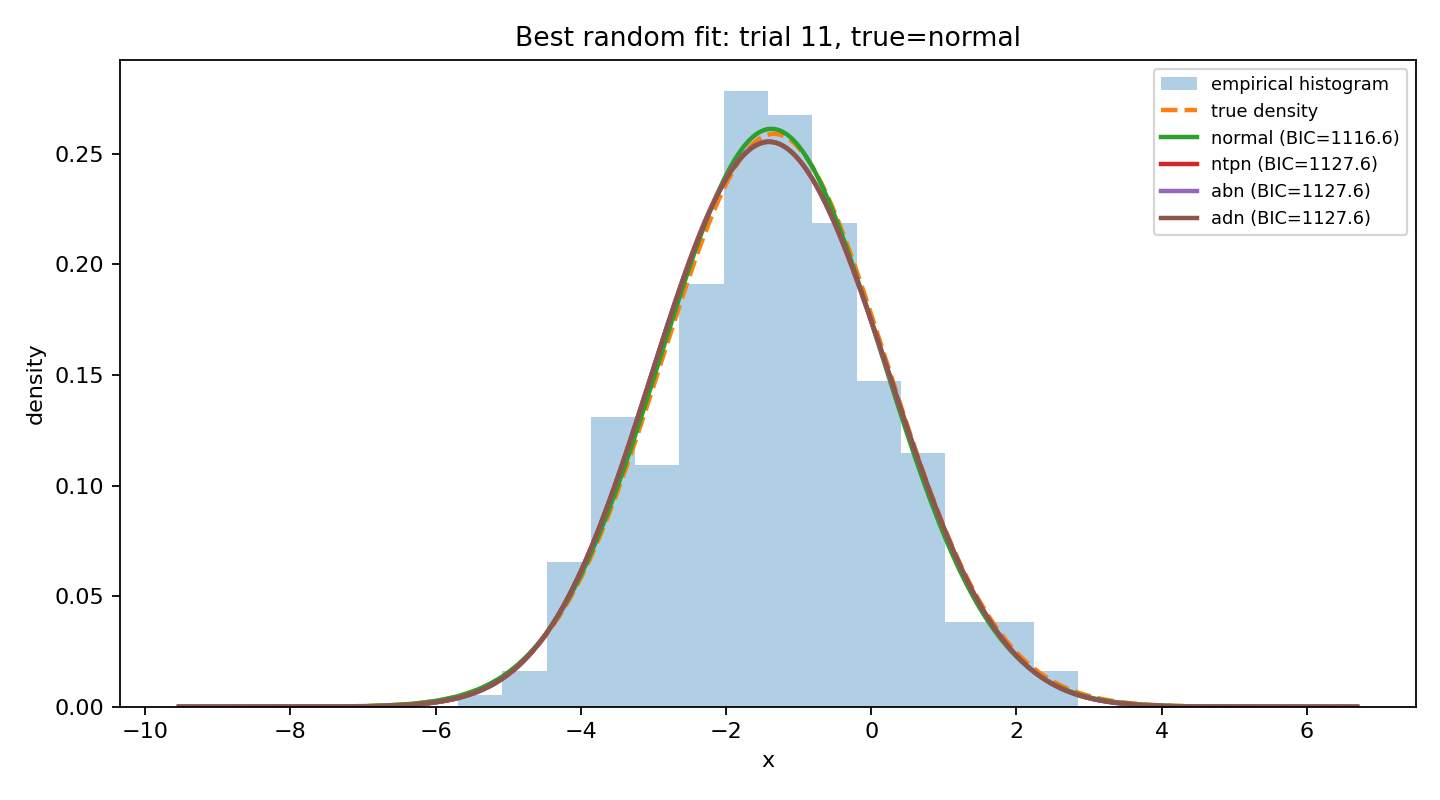

### Fixed scenario overlays

#### normal_unimodal_fit_overlay.png

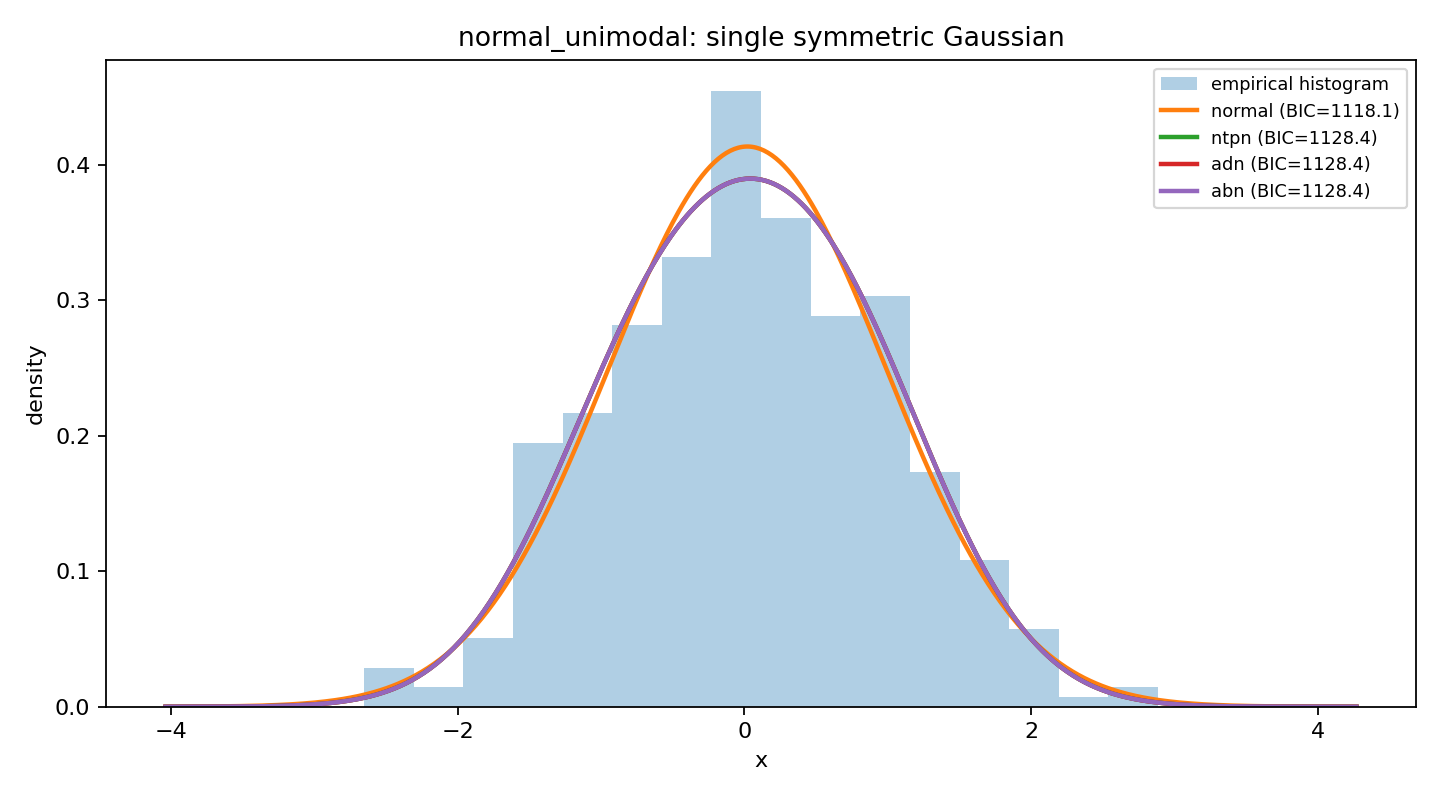

#### overlapping_gmm2_fit_overlay.png

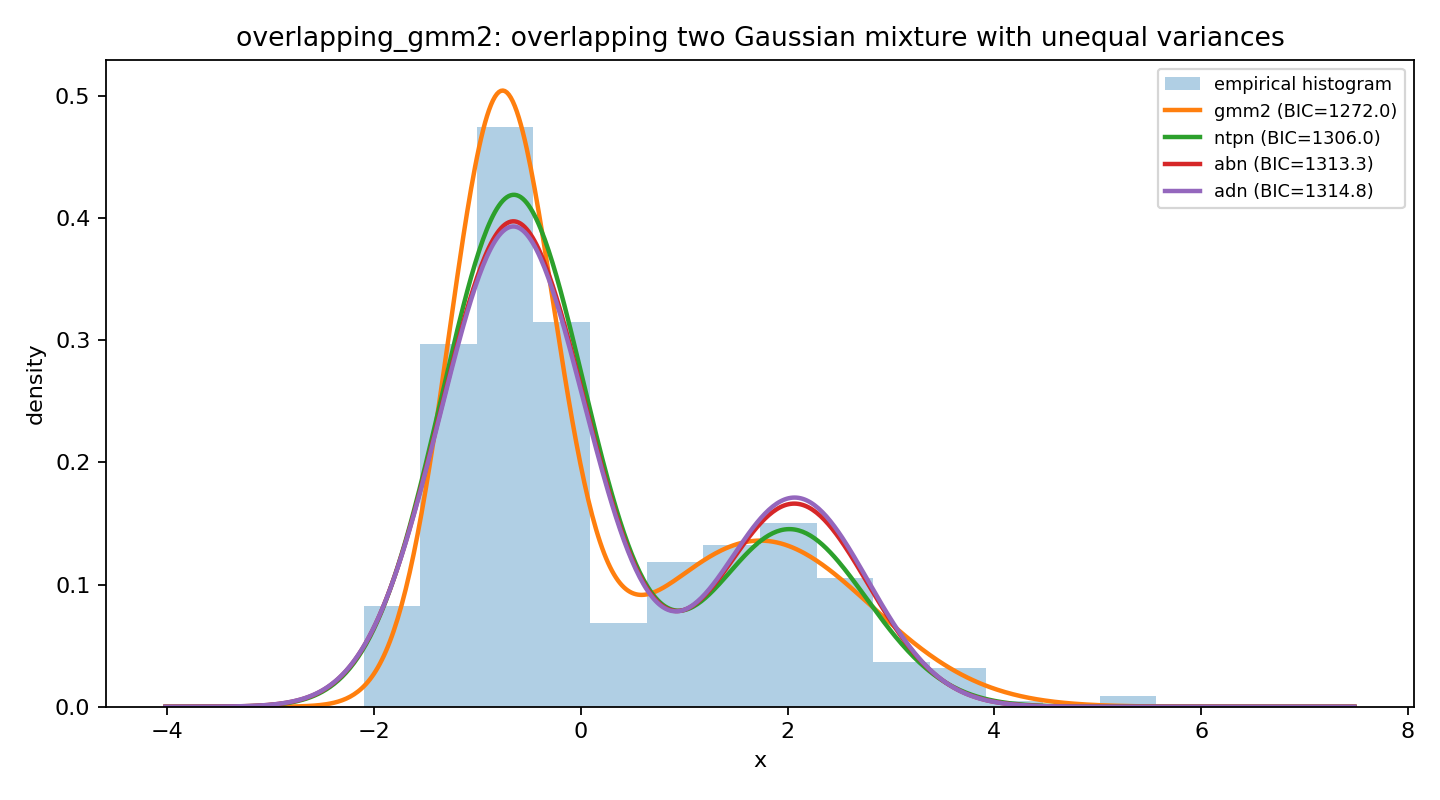

#### skewed_bimodal_mixture_fit_overlay.png

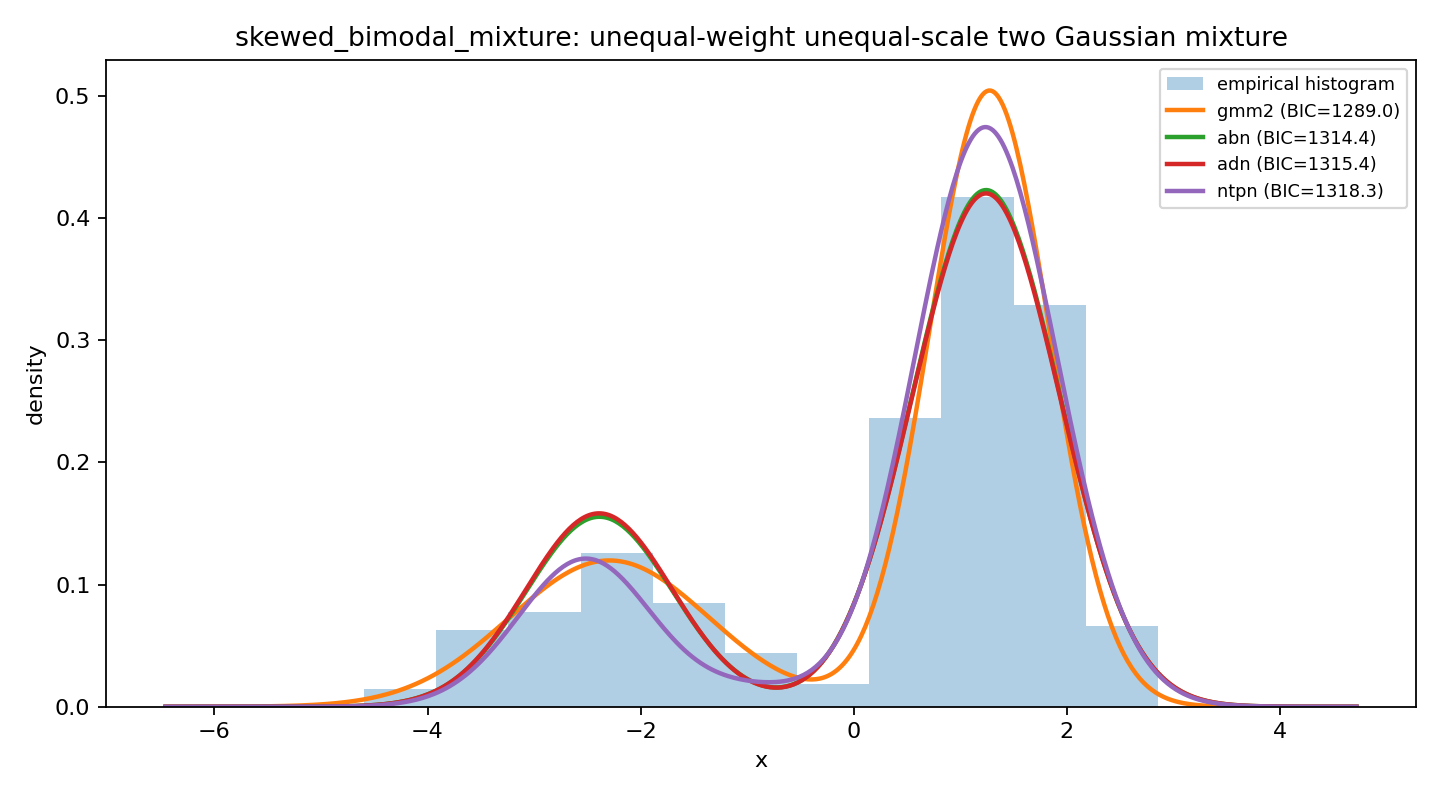

#### skewed_unimodal_fit_overlay.png

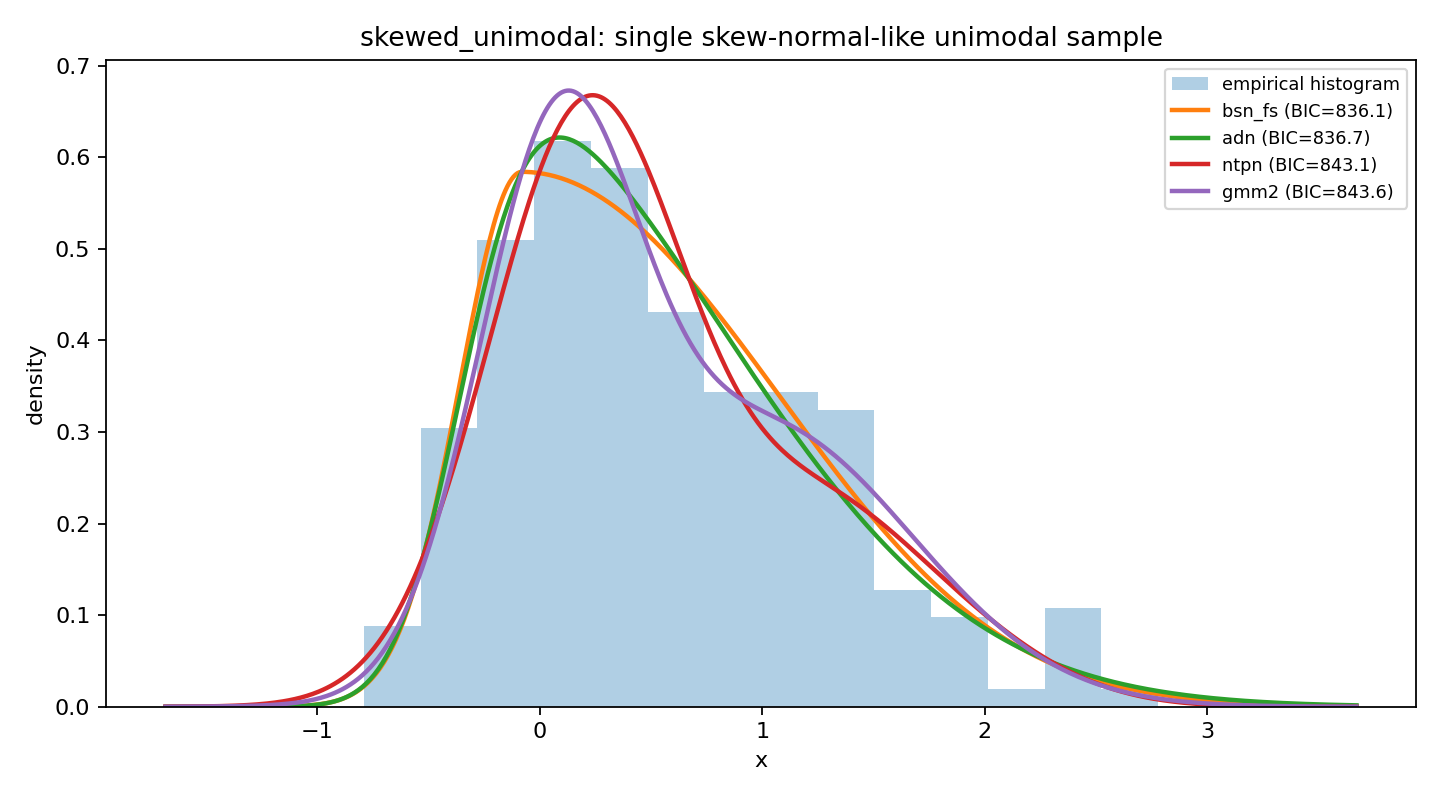

#### symmetric_bimodal_fit_overlay.png

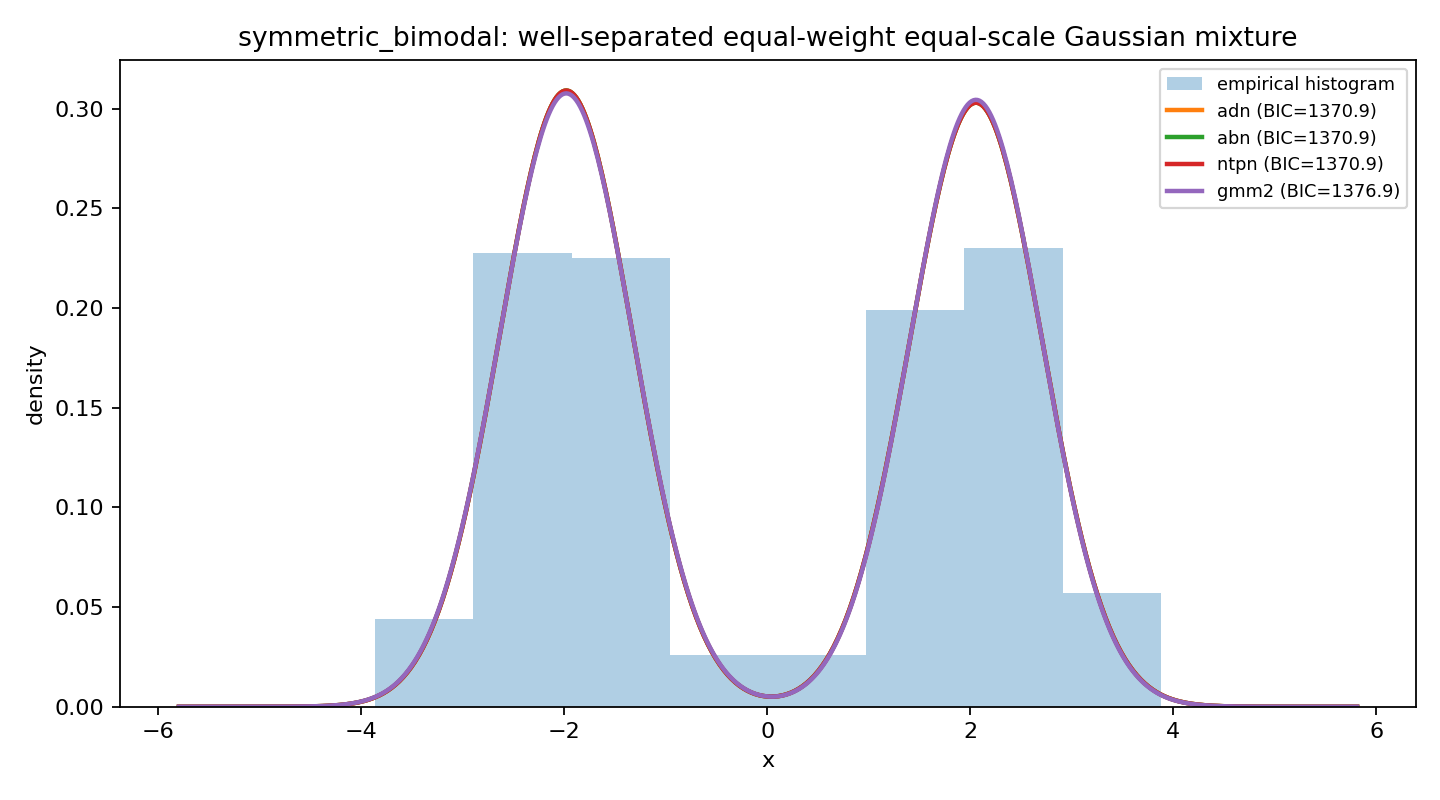

In [5]:
display(Markdown('### Best randomized fit overlay'))
display(Image(filename=str(OUTPUTS / 'random_search_best_fit.png')))
display(Markdown('### Fixed scenario overlays'))
for path in sorted(OUTPUTS.glob('*_fit_overlay.png')):
    display(Markdown(f'#### {path.name}'))
    display(Image(filename=str(path)))